# property, decorator und descriptor
## 1️⃣ Was ist property formal? Antwort: Ein eingebauter Descriptor-Typ, geschrieben in C, aber konzeptionell gut in Python nachbaubar.
- 👉 property ist eine Klasse
- 👉 Instanzen davon sind Descriptors

## 2️⃣ Warum ist property ein Descriptor?

Ein Descriptor ist jedes Objekt mit mindestens einer dieser Methoden:

__get__

__set__

__delete__

Und property hat alle drei.

# Die entscheidenden Details der Implementierung:
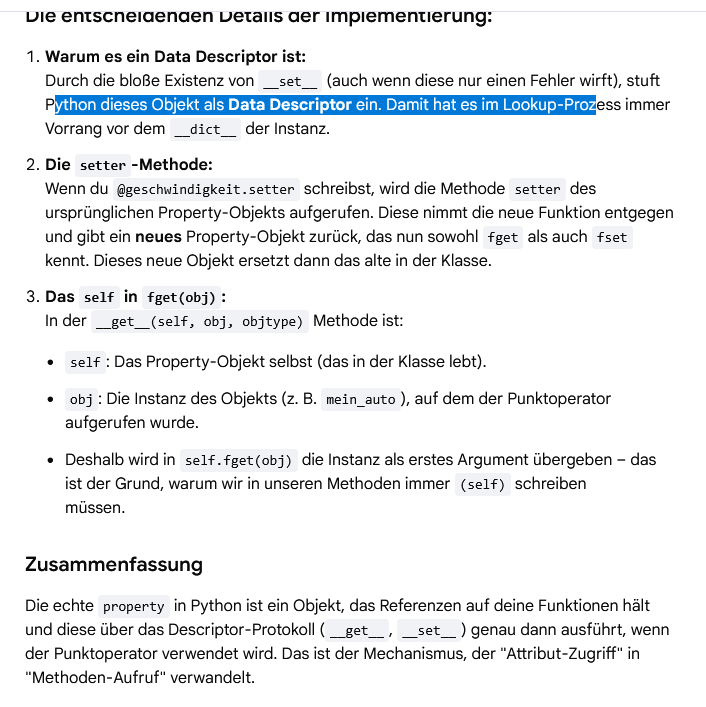

In [2]:
class Property:
    """Nachbildung der eingebauten property-Klasse."""

    def __init__(self, fget=None, fset=None, fdel=None, doc=None):
        self.fget = fget
        self.fset = fset
        self.fdel = fdel
        if doc is None and fget is not None:
            self.__doc__ = fget.__doc__
        else:
            self.__doc__ = doc

    # Das Descriptor-Protokoll: Das Herzstück
    # self: property object, obj: a class object(user defined), objtype
    def __get__(self, obj, objtype=None):
        if obj is None:
            # Zugriff über die Klasse (z.B. Auto.geschwindigkeit)
            return self
        if self.fget is None:
            raise AttributeError("unreadable attribute")
        # Ruft deine @property-Methode auf und übergibt die Instanz (self)
        return self.fget(obj)

    def __set__(self, obj, value):
        if self.fset is None:
            # Hier passiert der Fehler, wenn kein @setter definiert wurde!
            raise AttributeError("can't set attribute")
        # Ruft deine @name.setter-Methode auf
        self.fset(obj, value)

    def __delete__(self, obj):
        if self.fdel is None:
            raise AttributeError("can't delete attribute")
        self.fdel(obj)

    # Die Methoden für die Decorator-Syntax
    def setter(self, fset):
        # Erzeugt eine NEUE Property-Instanz mit dem hinzugefügten Setter
        return type(self)(self.fget, fset, self.fdel, self.__doc__)

    def deleter(self, fdel):
        return type(self)(self.fget, self.fset, fdel, self.__doc__)


In [2]:
print(property)
print(type(property))


<class 'property'>
<class 'type'>


In [3]:
p = property(lambda self: 42)
print(type(p))


<class 'property'>


In [4]:
class MyProperty:
    def __init__(self, fget=None, fset=None, fdel=None):
        self.fget = fget
        self.fset = fset
        self.fdel = fdel

    def __get__(self, instance, owner):
        if instance is None:
            return self
        if self.fget is None:
            raise AttributeError("unreadable attribute")
        return self.fget(instance)

    def __set__(self, instance, value):
        if self.fset is None:
            raise AttributeError("can't set attribute")
        self.fset(instance, value)

    def __delete__(self, instance):
        if self.fdel is None:
            raise AttributeError("can't delete attribute")
        self.fdel(instance)


# Inner- and aussen funktion mit gleichem Name

In [12]:
def myfunc(n):
    def myfunc(name): #inner function with the same name
        if n==1:
            print("my name is :", name)
        else:
            print("my name is :", None)       
    return myfunc
    
func= myfunc(1) 
func("Chen")

my name is : Chen


# was ist der Unterschied zwischen decorator und descriptor? 
1. Decorator
Ein Decorator ist ein Callable (meist eine Funktion), das eine andere Funktion entgegennimmt und eine modifizierte Version davon zurückgibt. Er wird mit dem @-Symbol markiert.
2. Descriptor
Ein Descriptor ist eine **Klasse**, die mindestens eine der Methoden __get__, __set__ oder __delete__ implementiert. Er wird als Klassenattribut in einer anderen Klasse definiert, um das Verhalten dieses Attributs zu steuern.

In [14]:
# decorator
def mein_decorator(func):
    def wrapper():
        print("Vor dem Aufruf.")
        func()
        print("Nach dem Aufruf.")
    return wrapper

@mein_decorator
def sage_hallo():
    print("Hallo!")

sage_hallo()


Vor dem Aufruf.
Hallo!
Nach dem Aufruf.


In [17]:
# descriptor
class ValidierteZahl:
    def __set_name__(self, owner, name):
        self.name = name

    def __set__(self, instance, value):
        if value < 0:
            raise ValueError(f"{self.name} darf nicht negativ sein!")
        instance.__dict__[self.name] = value

    def __get__(self, instance, owner):
        return instance.__dict__.get(self.name)

class Produkt:
    preis = ValidierteZahl() # Dies ist der Descriptor

p = Produkt()
p.preis = 10  # Ruft __set__ auf
# p.preis = -5 # Würde ValueError auslösen
p.preis


10